1. Membaca Data Analitik...
2. Menyiapkan Fitur (X) dan Target (y)...
3. Memecah Data (Train-Test Split)...
4. Melatih Model (Random Forest Classifier)...
5. Evaluasi Prediksi Churn...

--- Laporan Akurasi Klasifikasi ---
              precision    recall  f1-score   support

           0       0.67      0.71      0.69      7645
           1       0.79      0.76      0.78     11027

    accuracy                           0.74     18672
   macro avg       0.73      0.74      0.73     18672
weighted avg       0.74      0.74      0.74     18672



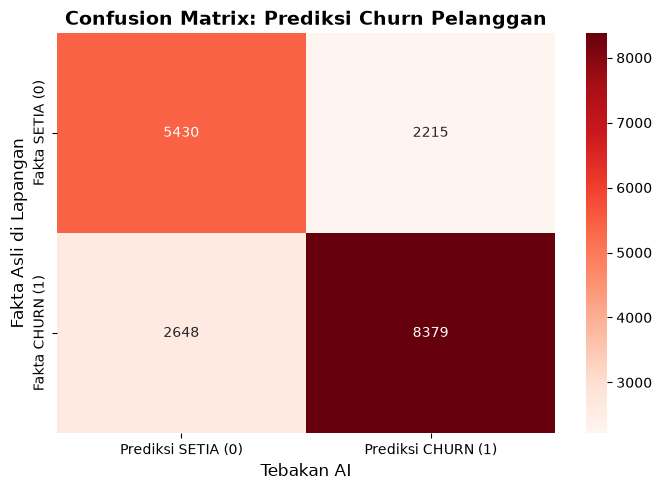

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("1. Membaca Data Analitik...")
df = pd.read_parquet('../data/processed/rfm_churn_data.parquet')

print("2. Menyiapkan Fitur (X) dan Target (y)...")
X = df[['frequency', 'monetary']]
y = df['is_churn']

print("3. Memecah Data (Train-Test Split)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("4. Melatih Model (Random Forest Classifier)...")
# Menggunakan class_weight='balanced' untuk menangani ketimpangan data (imbalanced data)
model_churn = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_churn.fit(X_train, y_train)

print("5. Evaluasi Prediksi Churn...")
prediksi = model_churn.predict(X_test)

print("\n--- Laporan Akurasi Klasifikasi ---")
print(classification_report(y_test, prediksi))

# 6. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, prediksi)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Prediksi SETIA (0)', 'Prediksi CHURN (1)'],
            yticklabels=['Fakta SETIA (0)', 'Fakta CHURN (1)'])

plt.title('Confusion Matrix: Prediksi Churn Pelanggan', fontsize=14, fontweight='bold')
plt.xlabel('Tebakan AI', fontsize=12)
plt.ylabel('Fakta Asli di Lapangan', fontsize=12)
plt.tight_layout()
plt.show()